In [ ]:
# HEART DISEASE PREDICTION SYSTEM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Dataset

df = pd.read_csv("/content/heart.csv")
print(df)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [4]:

#  Data Understanding

print("\n========= FIRST 10 ROWS =========")
print(df.head(10))

print("\n========= SHAPE =========")
print(df.shape)

print("\n========= INFO =========")
print(df.info())

print("\n========= STATISTICS =========")
print(df.describe())


========= FIRST 10 ROWS =========
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      

In [5]:

# Check Missing Values & Duplicates

print("\n========= MISSING VALUES =========")
print(df.isnull().sum())

print("\n========= DUPLICATES =========")
print(df.duplicated().sum())

# Remove duplicates

df.drop_duplicates(inplace=True)


========= MISSING VALUES =========
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

========= DUPLICATES =========
0


In [6]:
# Encode Categorical Columns

encoder = LabelEncoder()

categorical_cols = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40    1              1        140          289          0           1   
1   49    0              2        160          180          0           1   
2   37    1              1        130          283          0           2   
3   48    0              0        138          214          0           1   
4   54    1              2        150          195          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0    172               0      0.0         2             0  
1    156               0      1.0         1             1  
2     98               0      0.0         2             0  
3    108               1      1.5         1             1  
4    122               0      0.0         2             0  


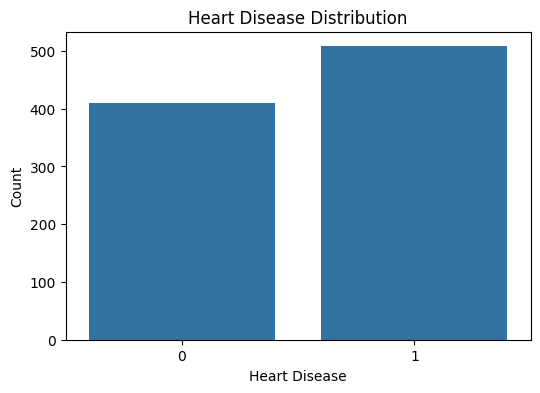

In [8]:
# Exploratory Data Analysis

plt.figure(figsize=(6,4))

sns.countplot(x='HeartDisease', data=df)

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

plt.show()

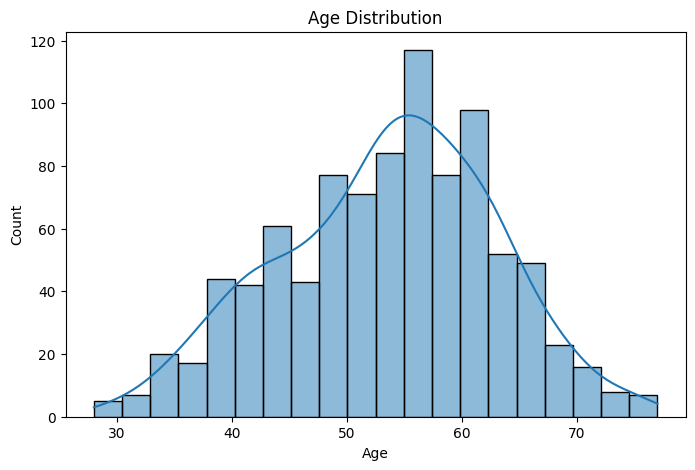

In [9]:
#  Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.show()

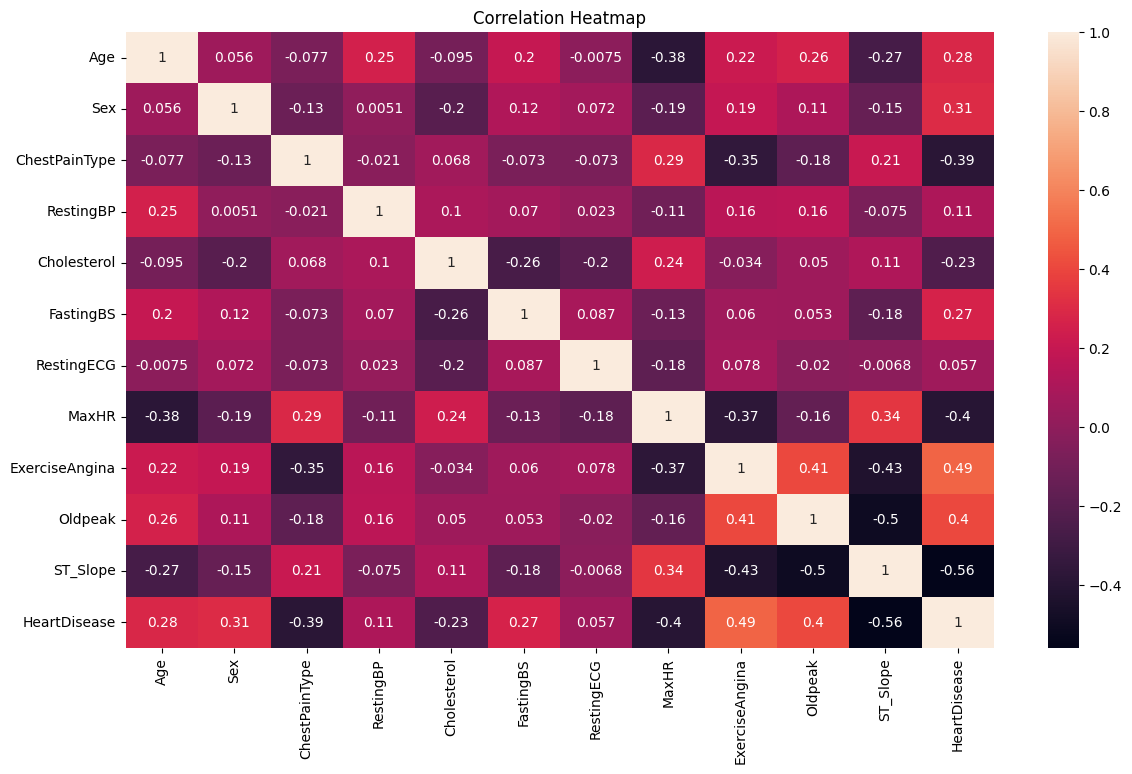

In [10]:
# Correlation Heatmap
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(), annot=True)

plt.title('Correlation Heatmap')

plt.show()

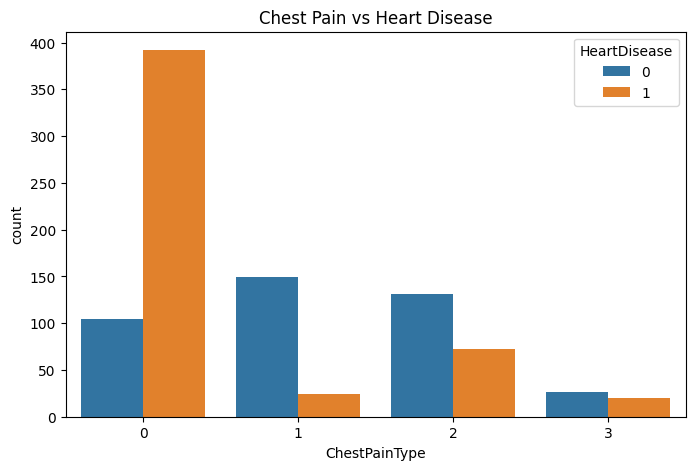

In [12]:
# Chest Pain Analysis

plt.figure(figsize=(8,5))

sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)

plt.title('Chest Pain vs Heart Disease')

plt.show()

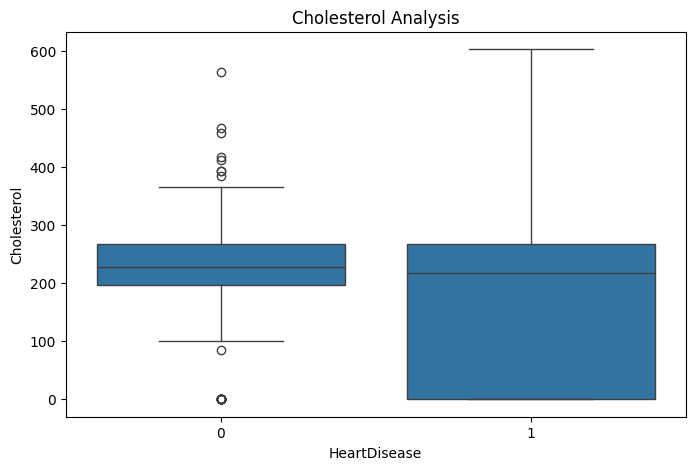

In [13]:
# Cholesterol Analysis

plt.figure(figsize=(8,5))

sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

plt.title('Cholesterol Analysis')

plt.show()

In [14]:
# Define Features and Target

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [15]:
# Split Dataset


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
# Feature Scaling


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Train Multiple Models

models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

results = {}

In [18]:
# Model Training & Testing

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(f"\n========== {name} ==========")
    print("Accuracy:", accuracy)

    print("\nClassification Report")
    print(classification_report(y_test, predictions))


========== Logistic Regression ==========
Accuracy: 0.8478260869565217

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


========== SVM ==========
Accuracy: 0.8641304347826086

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184


========== Decision Tree ==========
Accuracy: 0.7880434782608695

Classification Report
              precision    recall  f1-score   support

           0       0.71     

In [19]:
# Accuracy Comparison


accuracy_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': results.values()
})

print(accuracy_df)

                 Model  Accuracy
0  Logistic Regression  0.847826
1                  SVM  0.864130
2        Decision Tree  0.788043
3        Random Forest  0.875000


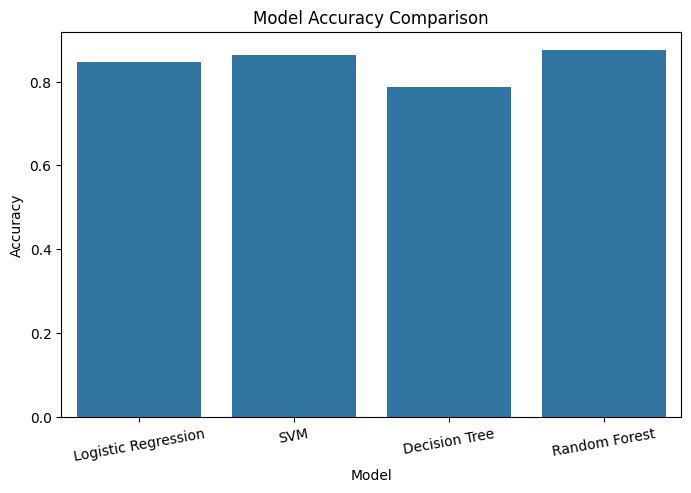

In [20]:
# Accuracy Visualization

plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy', data=accuracy_df)

plt.title('Model Accuracy Comparison')

plt.xticks(rotation=10)

plt.show()

In [21]:
# Best Model Selection

best_model_name = max(results, key=results.get)

print("\nBest Model is:", best_model_name)


Best Model is: Random Forest


In [22]:
#  Use Random Forest for Final Prediction

final_model = RandomForestClassifier()

final_model.fit(X_train, y_train)

RandomForestClassifier()

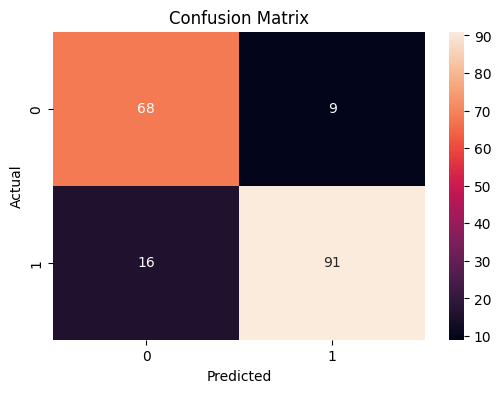

In [23]:
#  Confusion Matrix

final_predictions = final_model.predict(X_test)

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

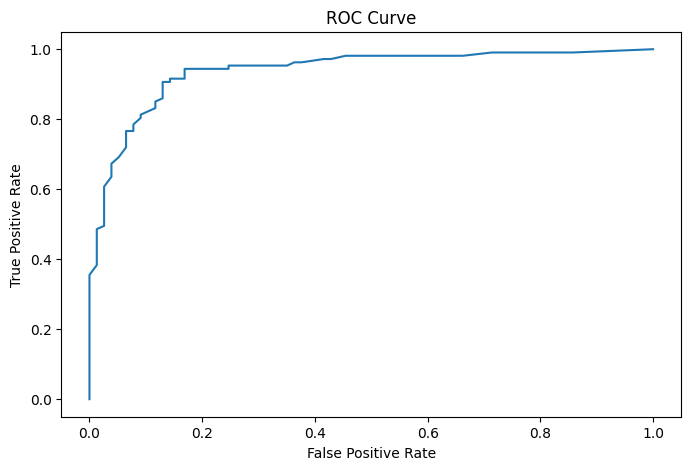

In [24]:
#  ROC Curve

probabilities = final_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, probabilities)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

In [25]:
# Manual Prediction System

sample_patient = [[
    48,
    1,
    2,
    130,
    245,
    0,
    1,
    150,
    0,
    1.2,
    2
]]

sample_patient = scaler.transform(sample_patient)

prediction = final_model.predict(sample_patient)

print("\n========= FINAL RESULT =========")

if prediction[0] == 1:
    print("Patient has Heart Disease")
else:
    print("Patient is Normal")


========= FINAL RESULT =========
Patient is Normal


In [26]:
#  Save Model
import pickle

pickle.dump(final_model, open('heart_disease_model.pkl', 'wb'))

print("\nModel Saved Successfully")






Model Saved Successfully


In [27]:

# Final Project Conclusion


print("""
=====================================
PROJECT COMPLETED SUCCESSFULLY
=====================================

Project Name:
Heart Disease Prediction Using Machine Learning

Algorithms Used:
1. Logistic Regression
2. SVM
3. Decision Tree
4. Random Forest

Technologies:
Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn

=====================================
""")


PROJECT COMPLETED SUCCESSFULLY

Project Name:
Heart Disease Prediction Using Machine Learning

Algorithms Used:
1. Logistic Regression
2. SVM
3. Decision Tree
4. Random Forest

Technologies:
Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn


